# Model Performance: Accuracy and Confusion Matrix

Evaluation of the multi-agent SMS recruiting bot on the labelled dataset
(`data/sms_conversations.json`): 15 conversations, 103 turns, of which **59
recruiter turns carry a label** - `continue` 25, `schedule` 19, `end` 15.

**Method.** Evaluation is *teacher-forced*: each labelled recruiter turn is
predicted from the recorded history preceding it, not from the agent's own
earlier messages. Every turn is therefore an independent classification and one
early mistake cannot cascade. The schedule store is opened read-only so replays
never book slots and never mutate the calendar.

**Split.** Conversations 1-10 are training (used for few-shot examples and the
fine-tuning JSONL); conversations 11-15 are held out and never shown to a model.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "tests" else Path.cwd()
RESULTS = ROOT / "results"
ACTIONS = ["continue", "schedule", "end"]
TEST_IDS = set(range(11, 16))

def load(name):
    path = RESULTS / f"{name}.json"
    return json.loads(path.read_text()) if path.exists() else None

def accuracy(preds):
    return sum(p["expected"] == p["predicted"] for p in preds) / len(preds) if preds else 0.0

def confusion(preds):
    m = np.zeros((3, 3), dtype=int)
    idx = {a: i for i, a in enumerate(ACTIONS)}
    for p in preds:
        m[idx[p["expected"]], idx[p["predicted"]]] += 1
    return m

def per_class(preds):
    m = confusion(preds)
    rows = []
    for i, action in enumerate(ACTIONS):
        tp = m[i, i]; fn = m[i].sum() - tp; fp = m[:, i].sum() - tp
        prec = tp / (tp + fp) if tp + fp else 0.0
        rec = tp / (tp + fn) if tp + fn else 0.0
        f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
        rows.append((action, prec, rec, f1, tp + fn))
    return rows

print("cached results:", sorted(p.stem for p in RESULTS.glob("*.json")))

cached results: ['baselines', 'llm_run1', 'llm_run2', 'llm_run3', 'llm_tools', 'rule']


## 1. Trivial baselines

Before reading any score, note what a system with no intelligence achieves.
Every conversation's **final** recruiter turn is labelled `end`, so a one-line
positional rule already scores 100% recall on that class. Any real system must
clear these floors to have demonstrated anything.

In [2]:
baselines = load("baselines")
if baselines:
    for name, acc in sorted(baselines.items(), key=lambda kv: -kv[1]):
        print(f"{acc:>7.1%}   {name}")
    BEST_BASELINE = max(baselines.values())
else:
    BEST_BASELINE = 0.0
    print("run: python -m app.modules.evaluation.run_eval --system rule")

  67.8%   baseline: last turn = end, else continue
  42.4%   baseline: always 'continue'
  32.2%   baseline: always 'schedule'
  25.4%   baseline: always 'end'


## 2. Results per system

`rule` is the deterministic rule-based agent - no API calls, and the baseline
the LLM has to beat to justify its cost. `llm_tools` is the LangChain
multi-agent system with SQL function calling. `llm_finetuned` appears only if a
fine-tuned Exit Advisor was trained.

Single-run figures below; section 6 gives the honest multi-run picture.

In [3]:
systems = [(n, load(n)) for n in ("rule", "llm_tools", "llm_finetuned")]
systems = [(n, r) for n, r in systems if r]

print(f"{'system':<34}{'all 59':>10}{'held-out 19':>14}")
print("-" * 58)
summary = {}
for name, report in systems:
    preds = report["predictions"]
    held = [p for p in preds if p["conversation_id"] in TEST_IDS]
    summary[name] = (accuracy(preds), accuracy(held), preds, held)
    print(f"{report['name'][:33]:<34}{accuracy(preds):>10.1%}{accuracy(held):>14.1%}")
print("-" * 58)
print(f"{'best trivial baseline':<34}{BEST_BASELINE:>10.1%}")

system                                all 59   held-out 19
----------------------------------------------------------
rule-based agent (no API)              79.7%         89.5%
LLM agent                              86.4%         94.7%
----------------------------------------------------------
best trivial baseline                  67.8%


## 3. Confusion matrices

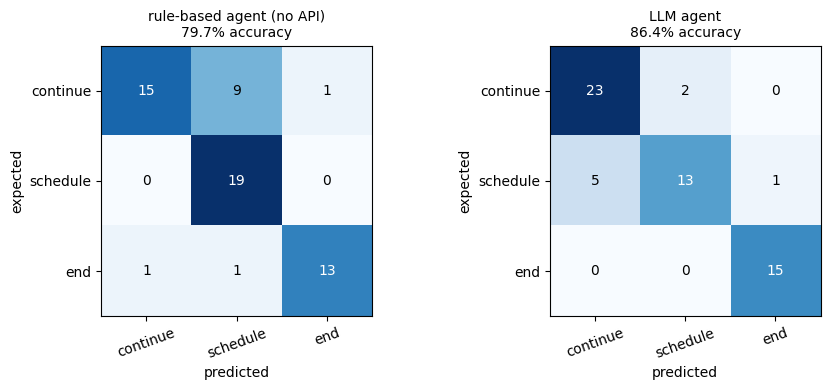

In [4]:
def plot_confusion(ax, preds, title):
    m = confusion(preds)
    ax.imshow(m, cmap="Blues")
    ax.set_xticks(range(3), ACTIONS, rotation=20)
    ax.set_yticks(range(3), ACTIONS)
    ax.set_xlabel("predicted"); ax.set_ylabel("expected")
    ax.set_title(f"{title}\n{accuracy(preds):.1%} accuracy", fontsize=10)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, m[i, j], ha="center", va="center",
                    color="white" if m[i, j] > m.max() / 2 else "black")

if systems:
    fig, axes = plt.subplots(1, len(systems), figsize=(4.6 * len(systems), 4))
    axes = np.atleast_1d(axes)
    for ax, (name, report) in zip(axes, systems):
        plot_confusion(ax, report["predictions"], report["name"][:38])
    plt.tight_layout(); plt.show()

## 4. Per-class precision, recall and F1

In [5]:
for name, report in systems:
    print(f"\n{report['name']}")
    print(f"  {'class':>10}{'prec':>8}{'recall':>8}{'f1':>8}{'n':>6}")
    for action, prec, rec, f1, n in per_class(report["predictions"]):
        print(f"  {action:>10}{prec:>8.2f}{rec:>8.2f}{f1:>8.2f}{n:>6}")


rule-based agent (no API)
       class    prec  recall      f1     n
    continue    0.94    0.60    0.73    25
    schedule    0.66    1.00    0.79    19
         end    0.93    0.87    0.90    15

LLM agent
       class    prec  recall      f1     n
    continue    0.82    0.92    0.87    25
    schedule    0.87    0.68    0.76    19
         end    0.94    1.00    0.97    15


## 5. Held-out results, and how much they can carry

The held-out split is **5 conversations / 19 labelled turns**. One turn is worth
5.3 accuracy points, so a difference of two or three turns between systems is
noise, not evidence. The numbers below are reported for completeness, not as a
basis for declaring a winner.

In [6]:
for name, (acc_all, acc_held, preds, held) in summary.items():
    delta = acc_held - acc_all
    print(f"{name:<16} all={acc_all:>6.1%}   held-out={acc_held:>6.1%}   ({delta:+.1%}, n={len(held)})")
print(f"\none held-out turn = {100/19:.1f} accuracy points")

rule             all= 79.7%   held-out= 89.5%   (+9.8%, n=19)
llm_tools        all= 86.4%   held-out= 94.7%   (+8.3%, n=19)

one held-out turn = 5.3 accuracy points


## 6. Run-to-run variance

The LLM classifiers run at `temperature=0`, but OpenAI does not guarantee
determinism, so the same code on the same data does not produce the same score
twice. Below are repeated runs of the *identical* system.

This is the single most important number in the notebook for interpreting
everything above it: the spread across runs is comparable to the gap between
systems, so any comparison resting on one run of each is not measuring what it
appears to measure.

In [7]:
# llm_tools is the current architecture (SQL function calling); llm_run1-3 are
# earlier runs of the same action pipeline - the tools cannot change the action,
# which is decided by the binary verdict before any tool is called.
runs = [(n, load(n)) for n in ("llm_run1", "llm_run2", "llm_run3", "llm_tools")]
runs = [(n, r) for n, r in runs if r]

if len(runs) > 1:
    all_acc, held_acc = [], []
    print(f"{'run':<12}{'all 59':>10}{'held-out 19':>14}")
    print("-" * 36)
    for name, report in runs:
        preds = report["predictions"]
        held = [p for p in preds if p["conversation_id"] in TEST_IDS]
        all_acc.append(accuracy(preds)); held_acc.append(accuracy(held))
        print(f"{name:<12}{accuracy(preds):>10.1%}{accuracy(held):>14.1%}")
    print("-" * 36)
    print(f"{'mean':<12}{np.mean(all_acc):>10.1%}{np.mean(held_acc):>14.1%}")
    print(f"{'spread':<12}{max(all_acc)-min(all_acc):>10.1%}{max(held_acc)-min(held_acc):>14.1%}")
    print("")
    print(f"Held-out spread is {(max(held_acc)-min(held_acc))*19:.0f} turns out of 19.")
    print("")
    print("The best run is the one with SQL function calling, but that is NOT")
    print("evidence the tools improved accuracy: the action is decided by the")
    print("binary verdict before any tool is called, so tools cannot change it.")
else:
    print("only one run cached; re-run with --tag llm_run2 to measure variance")

run             all 59   held-out 19
------------------------------------
llm_run1         84.7%         84.2%
llm_run2         84.7%         89.5%
llm_run3         84.7%         89.5%
llm_tools        86.4%         94.7%
------------------------------------
mean             85.2%         89.5%
spread            1.7%         10.5%

Held-out spread is 2 turns out of 19.

The best run is the one with SQL function calling, but that is NOT
evidence the tools improved accuracy: the action is decided by the
binary verdict before any tool is called, so tools cannot change it.


In [8]:
# Which turns are unstable? Turns that flip between runs are the ones
# carrying the variance - usually the genuinely ambiguous continue/schedule pairs.
if len(runs) > 1:
    by_turn = {}
    for name, report in runs:
        for p in report["predictions"]:
            by_turn.setdefault((p["conversation_id"], p["turn_id"]), []).append(p["predicted"])
    unstable = {k: v for k, v in by_turn.items() if len(set(v)) > 1}
    print(f"{len(unstable)} of {len(by_turn)} turns changed prediction between runs")
    print("")
    expected = {(p["conversation_id"], p["turn_id"]): p["expected"]
                for _, r in runs for p in r["predictions"]}
    for (cid, tid), preds in sorted(unstable.items()):
        print(f"  conv {cid:>2} turn {tid}: expected {expected[(cid, tid)]:<9} got {preds}")

3 of 59 turns changed prediction between runs

  conv  8 turn 3: expected schedule  got ['schedule', 'continue', 'continue', 'continue']
  conv 11 turn 7: expected schedule  got ['continue', 'continue', 'continue', 'schedule']
  conv 14 turn 3: expected schedule  got ['continue', 'schedule', 'schedule', 'schedule']


## 7. Where the errors are

The dominant confusion is `continue` predicted as `schedule`. Those are turns
where the recruiter chose to ask another question instead of proposing a time -
both are defensible replies to the same context, so this is partly irreducible
label ambiguity rather than a straightforward model error.

In [9]:
from collections import Counter
for name, report in systems:
    errors = Counter(
        (p["expected"], p["predicted"]) for p in report["predictions"]
        if p["expected"] != p["predicted"]
    )
    print(f"\n{report['name']}  ({sum(errors.values())} errors)")
    for (expected, predicted), count in errors.most_common():
        print(f"   expected {expected:<9} -> predicted {predicted:<9} x{count}")


rule-based agent (no API)  (12 errors)
   expected continue  -> predicted schedule  x9
   expected end       -> predicted schedule  x1
   expected continue  -> predicted end       x1
   expected end       -> predicted continue  x1

LLM agent  (8 errors)
   expected schedule  -> predicted continue  x5
   expected continue  -> predicted schedule  x2
   expected schedule  -> predicted end       x1


In [10]:
# A couple of concrete misses, for inspection.
name, report = systems[0]
misses = [p for p in report["predictions"] if p["expected"] != p["predicted"]][:3]
for p in misses:
    print(f"conv {p['conversation_id']} turn {p['turn_id']}: "
          f"expected {p['expected']}, predicted {p['predicted']}")
    if p.get("message"):
        print(f"   bot said: {p['message'][:110]}")
    print()

conv 2 turn 3: expected continue, predicted schedule
   bot said: Could we schedule your interview for Tuesday 30 Apr 2024 at 12:00 PM or Tuesday 30 Apr 2024 at 2:00 PM?

conv 2 turn 5: expected continue, predicted schedule
   bot said: Could we schedule your interview for Tuesday 30 Apr 2024 at 12:00 PM or Tuesday 30 Apr 2024 at 2:00 PM?

conv 3 turn 3: expected continue, predicted schedule
   bot said: Could we schedule your interview for Wednesday 10 Apr 2024 at 5:00 PM or Thursday 11 Apr 2024 at 10:00 AM?



## 8. Conclusions

1. **The `end` class is easier than it looks.** Every conversation's last turn is
   `end`, so a positional rule scores 100% recall on it. High `end` numbers
   should not be read as evidence that the Exit Advisor is working well.

2. **`schedule` is the discriminating class.** It is the one the bot must get
   right to achieve its goal, and it is the one that separates a reactive
   implementation from a proactive one: 10 of the 19 `schedule` turns follow the
   candidate's first answer with no request from them at all. An advisor that
   only fires when the candidate raises timing scores ~0.05 recall here.

3. **`continue` vs `schedule` is partly irreducible.** The remaining errors
   concentrate there, on turns where both replies are reasonable.

4. **The held-out split is too small to rank systems.** 19 turns; one turn is 5.3
   points. Section 6 shows this empirically: repeated runs of the identical
   system differ by several turns, so the run-to-run spread is comparable to the
   gap between systems. Treat the held-out column as a sanity check, never a
   leaderboard, and quote a range rather than a single figure.

5. **Fine-tuning could not be run.** OpenAI closed self-serve fine-tuning to new
   jobs (HTTP 403 `training_not_available`) while this project was being built.
   The complete pipeline is in `app/modules/fine_tuning/` - dataset builder,
   upload, launch, polling, and model-id plumbing - and the Exit Advisor accepts
   a fine-tuned model id through the same interface it already uses. Only the
   training job itself is missing, and it is blocked at the provider.